In [23]:
import os
import zipfile
import numpy as np
from PIL import Image, ImageEnhance
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import graycomatrix, graycoprops
from skimage.filters import sobel
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [25]:
# ZIP dosyasını çözme
zip_path = "C:/Users/bsanl/OneDrive/Masaüstü/veriseti.zip"
extract_path = "veriseti"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Veri yollarını tanımlama
yes_path = os.path.join(extract_path, "yes")
no_path = os.path.join(extract_path, "no")

In [26]:
# Görüntü boyutu
image_size = (128, 128)

# Görüntü ön işleme ve veri artırma
def preprocess_image(image, augment=False):
    image = image.convert('L')  # Gri tonlama
    image = image.resize(image_size)  # Boyutlandırma
    
    if augment:
        enhancer = ImageEnhance.Brightness(image)
        image = enhancer.enhance(1.5)  # Parlaklık artırma
    
    image = np.array(image).astype(np.uint8)  # Numpy array ve uint8 dönüştürme
    return image

# Ham görüntüleri yükleme ve ön işleme
def load_images_and_labels(path, label, augment=False):
    data, labels = [], []
    for file in os.listdir(path):
        try:
            img = Image.open(os.path.join(path, file))
            data.append(preprocess_image(img, augment=augment).flatten())
            labels.append(label)
        except Exception as e:
            print(f"Hata: {file} - {e}")
    return data, labels

# Tümörlü ve tümörsüz görüntüleri yükleme
yes_data, yes_labels = load_images_and_labels(yes_path, 1)
no_data, no_labels = load_images_and_labels(no_path, 0)

# Veri artırma (opsiyonel olarak artırılmış verileri ekleyebilirsiniz)
aug_yes_data, aug_yes_labels = load_images_and_labels(yes_path, 1, augment=True)
aug_no_data, aug_no_labels = load_images_and_labels(no_path, 0, augment=True)

# Verileri ve etiketleri birleştirme
data = np.array(yes_data + no_data + aug_yes_data + aug_no_data)
labels = np.array(yes_labels + no_labels + aug_yes_labels + aug_no_labels)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

In [27]:
# Özellik çıkarma fonksiyonu
def extract_features(image_array):
    features = []
    for image in image_array:
        image = image.reshape(image_size)
        
        # GLCM (doku analizi)
        glcm = graycomatrix(image, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
        contrast = graycoprops(glcm, 'contrast')[0, 0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
        
        # Kenar tespiti
        edge = sobel(image).flatten()
        edge_mean = edge.mean()
        
        # Histogram özellikleri
        hist, _ = np.histogram(image.flatten(), bins=256, range=(0, 256))
        hist_normalized = hist / hist.sum()
        
        features.append([contrast, homogeneity, edge_mean] + list(hist_normalized))
    return np.array(features)

# Özellik çıkarma
X_train_features = extract_features(X_train)
X_test_features = extract_features(X_test)

# Verileri normalize etme
scaler = StandardScaler()
X_train_features = scaler.fit_transform(X_train_features)
X_test_features = scaler.transform(X_test_features)



Model: SVM
Doğruluk: 0.8267
ROC-AUC Skoru: 0.8905
Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.80      0.85      0.83       581
           1       0.85      0.81      0.83       619

    accuracy                           0.83      1200
   macro avg       0.83      0.83      0.83      1200
weighted avg       0.83      0.83      0.83      1200



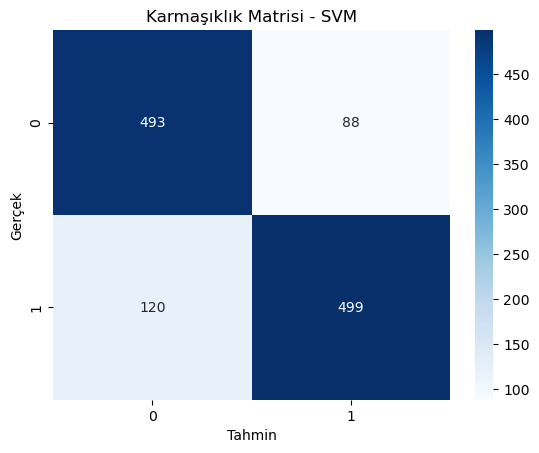

--------------------------------------------------
Model: Random Forest
Doğruluk: 0.9500
ROC-AUC Skoru: 0.9834
Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       581
           1       0.96      0.95      0.95       619

    accuracy                           0.95      1200
   macro avg       0.95      0.95      0.95      1200
weighted avg       0.95      0.95      0.95      1200



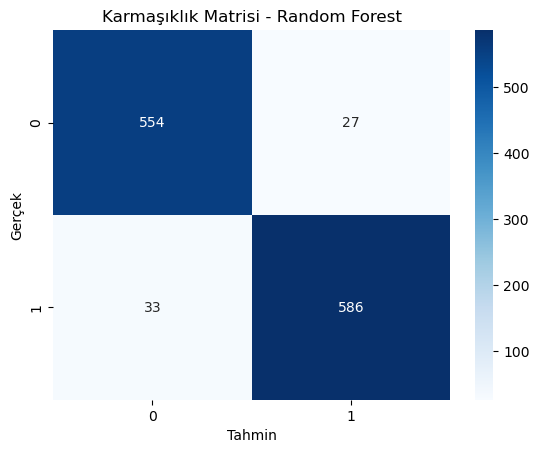

--------------------------------------------------
Model: Gradient Boosting
Doğruluk: 0.8933
ROC-AUC Skoru: 0.9492
Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       581
           1       0.91      0.88      0.89       619

    accuracy                           0.89      1200
   macro avg       0.89      0.89      0.89      1200
weighted avg       0.89      0.89      0.89      1200



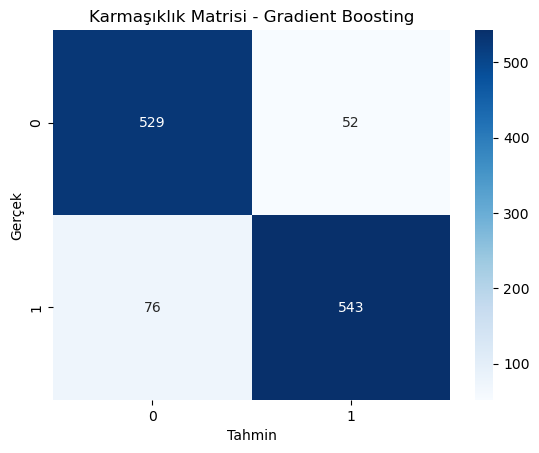

--------------------------------------------------
Model: KNN
Doğruluk: 0.9325
ROC-AUC Skoru: 0.9726
Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       581
           1       0.94      0.93      0.93       619

    accuracy                           0.93      1200
   macro avg       0.93      0.93      0.93      1200
weighted avg       0.93      0.93      0.93      1200



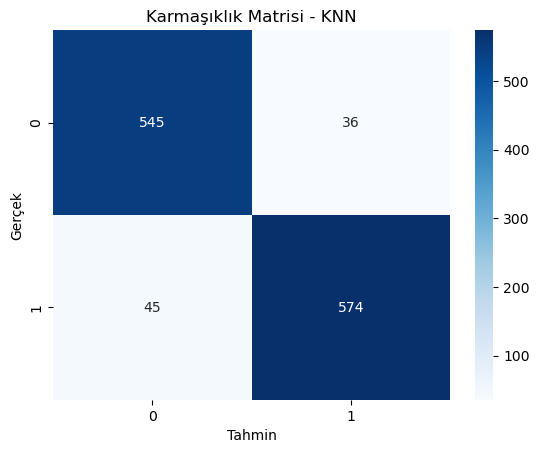

--------------------------------------------------
Model: Logistic Regression
Doğruluk: 0.8233
ROC-AUC Skoru: 0.8926
Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       581
           1       0.84      0.81      0.83       619

    accuracy                           0.82      1200
   macro avg       0.82      0.82      0.82      1200
weighted avg       0.82      0.82      0.82      1200



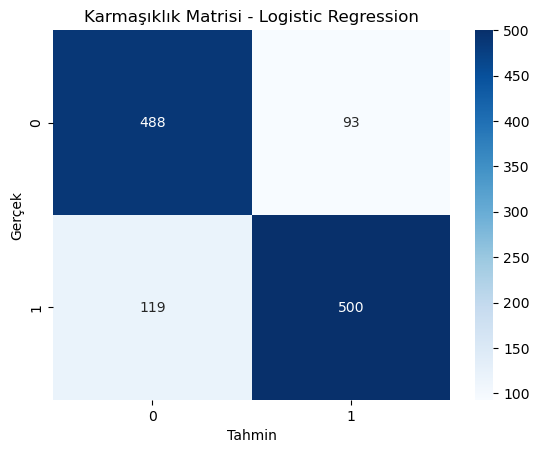

--------------------------------------------------


In [28]:
# Modelleri tanımlama
models = {
    "SVM": SVC(kernel='linear', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(random_state=42, solver='saga', max_iter=1000)
    
}

# Modelleri değerlendirme
for name, model in models.items():
    print(f"Model: {name}")
    model.fit(X_train_features, y_train)
    y_pred = model.predict(X_test_features)
    y_pred_proba = model.predict_proba(X_test_features)[:, 1] if hasattr(model, "predict_proba") else None

    # Doğruluk hesaplama
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Doğruluk: {accuracy:.4f}")
    
    # ROC-AUC skoru
    if y_pred_proba is not None:
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"ROC-AUC Skoru: {auc:.4f}")
    
    # Sınıflandırma raporu
    print("Sınıflandırma Raporu:")
    print(classification_report(y_test, y_pred))
    
    # Karmaşıklık matrisi
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Karmaşıklık Matrisi - {name}")
    plt.xlabel("Tahmin")
    plt.ylabel("Gerçek")
    plt.show()

    print("-" * 50)

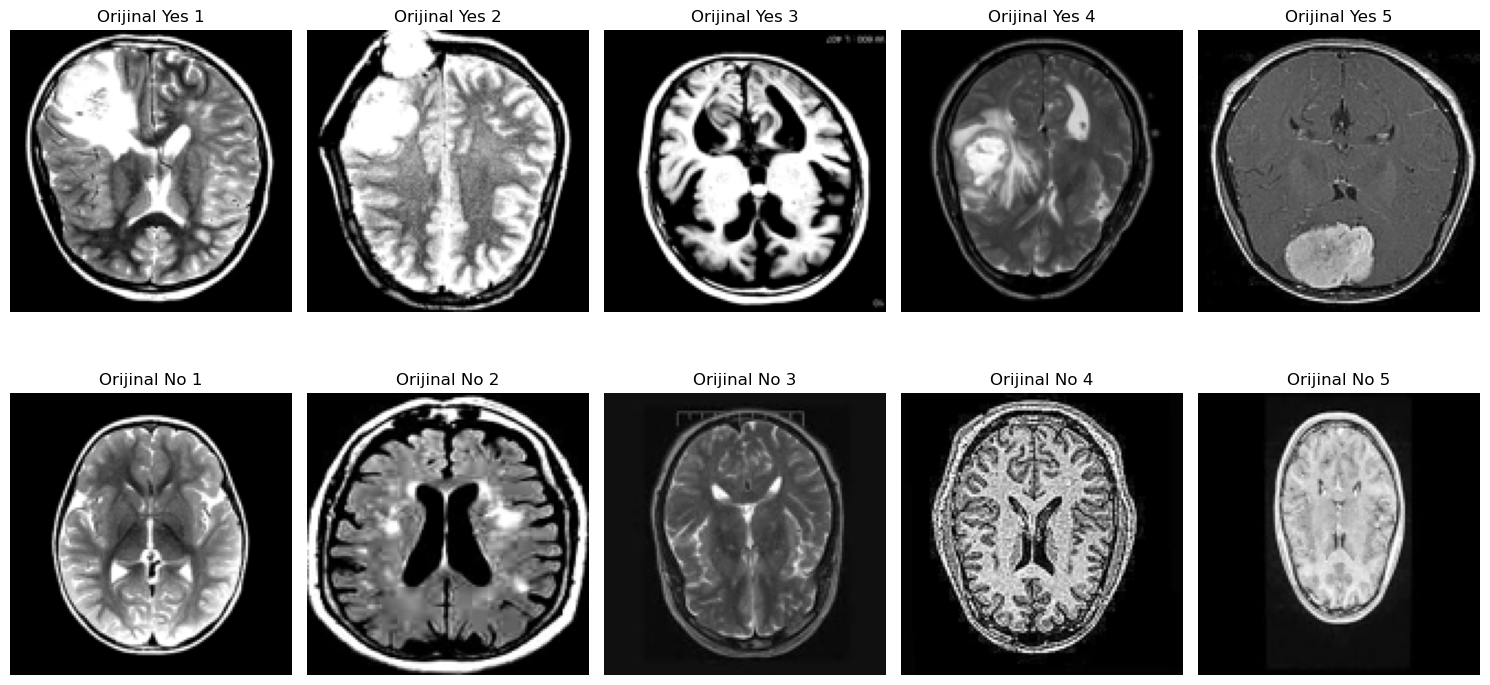

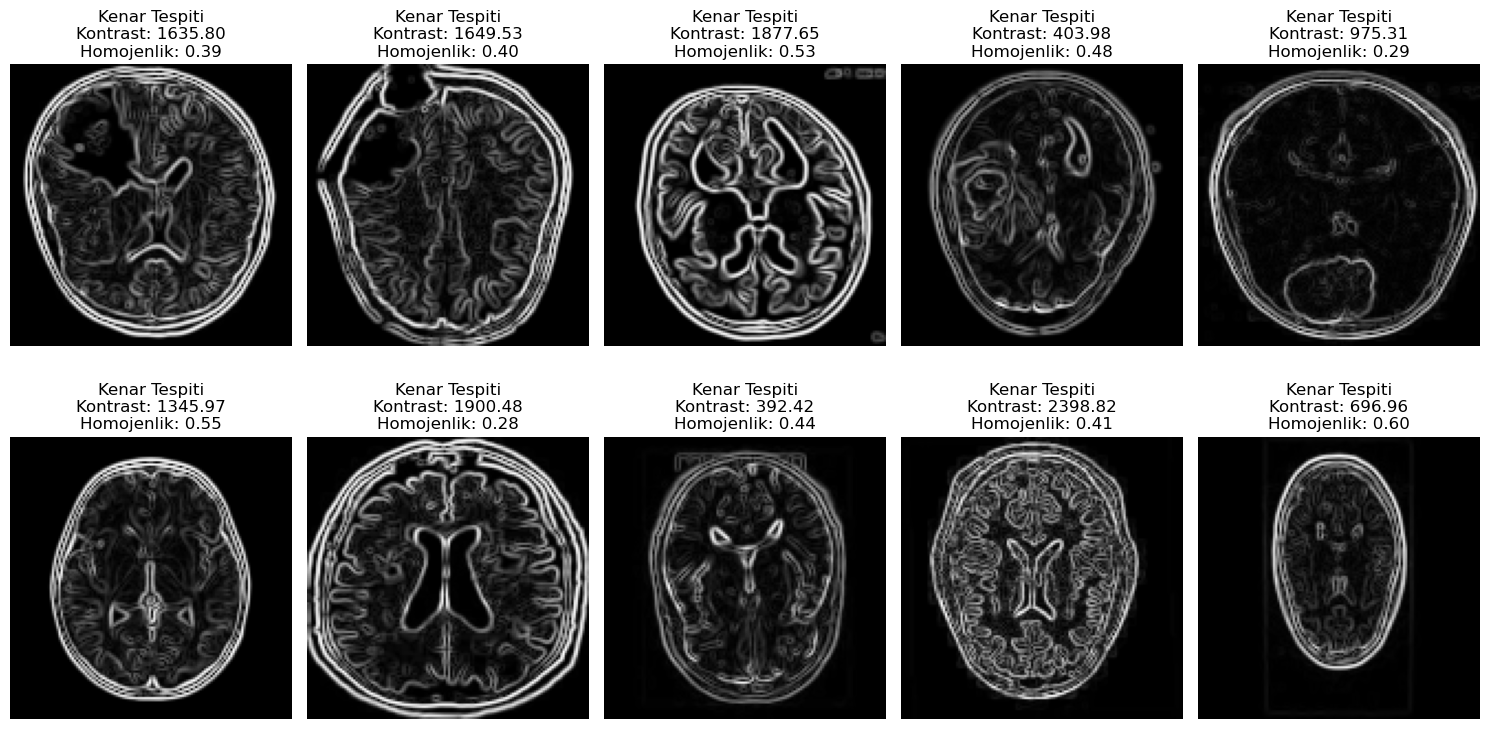

In [35]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os
from skimage.feature import graycomatrix, graycoprops
from skimage.filters import sobel

# Görüntü boyutu
image_size = (128, 128)

def load_images_and_show(path, show_count=5):
    images = []
    for i, file in enumerate(os.listdir(path)):
        if i >= show_count:
            break
        try:
            img = Image.open(os.path.join(path, file)).convert('L').resize(image_size)
            images.append(np.array(img))
        except Exception as e:
            print(f"Hata: {file} - {e}")
    
    return images

def extract_features(images):
    features_images = []
    for image in images:
        # GLCM (doku analizi) özelliklerini çıkarma
        glcm = graycomatrix(image, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
        contrast = graycoprops(glcm, 'contrast')[0, 0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
        
        # Kenar tespiti
        edge = sobel(image)
        
        # Histogram özellikleri çıkarma
        hist, _ = np.histogram(image.flatten(), bins=256, range=(0, 256))
        hist_normalized = hist / hist.sum()  # Normalizasyon
        
        # Özellik çıkarmadan sonraki görselleri kaydetme
        features_images.append((edge, contrast, homogeneity, hist_normalized))
    
    return features_images

# Orijinal görüntüleri yükleyip göster
yes_path = "C:/Users/bsanl/OneDrive/Masaüstü/yes"  # "Yes" kategorisi için klasör yolu
no_path = "C:/Users/bsanl/OneDrive/Masaüstü/no"    # "No" kategorisi için klasör yolu

yes_images = load_images_and_show(yes_path, show_count=5)
no_images = load_images_and_show(no_path, show_count=5)

# Özellik çıkarma işlemi (kenar tespiti, GLCM, ve histogram)
all_images = yes_images + no_images
features_images = extract_features(all_images)

# Orijinal görüntüleri görselleştirme
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    if i < len(yes_images):
        ax.imshow(yes_images[i], cmap='gray')
        ax.axis('off')
        ax.set_title(f"Orijinal Yes {i+1}")
    elif i < len(yes_images) + len(no_images):
        ax.imshow(no_images[i - len(yes_images)], cmap='gray')
        ax.axis('off')
        ax.set_title(f"Orijinal No {i - len(yes_images) + 1}")
    else:
        ax.axis('off')  # Ekstra alanları boş bırak

plt.tight_layout()
plt.show()

# Özellik çıkarılmış görüntüleri görselleştirme
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    if i < len(features_images):
        edge, contrast, homogeneity, hist_normalized = features_images[i]
        ax.imshow(edge, cmap='gray')
        ax.axis('off')
        ax.set_title(f"Kenar Tespiti\nKontrast: {contrast:.2f}\nHomojenlik: {homogeneity:.2f}")
    else:
        ax.axis('off')  # Ekstra alanları boş bırak

plt.tight_layout()
plt.show()

